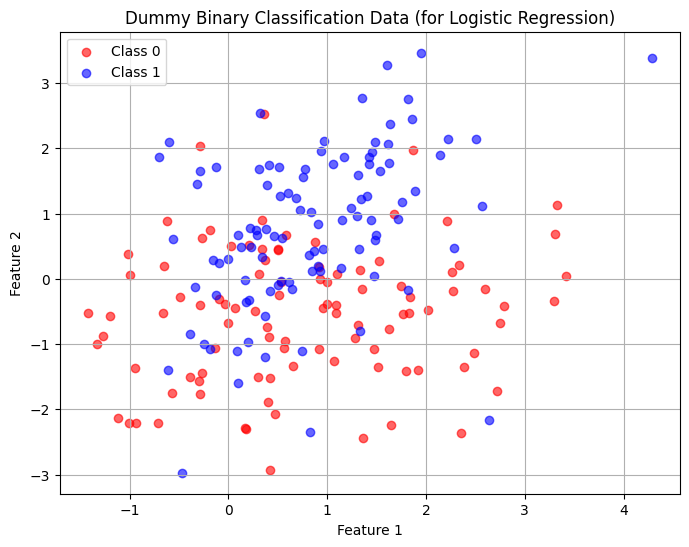

Features shape: (200, 2)
Target shape: (200,)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import math

# Set seed
np.random.seed(42)

# Generate a classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=2,          # Only 2 useful features for visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.8,         # Low separation makes it harder
    flip_y=0.1,            # Add noise (10% label flipping)
    random_state=42
)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

print("Features shape:", x.shape)
print("Target shape:", y.shape)

In [2]:
def sigmoid_function(z):
    sigmoid = 1/(1 + np.exp(-z))

    return sigmoid

In [3]:
y_reshape = y.reshape(-1,1)
y_reshape.shape

(200, 1)

In [4]:
# Standardize features using Z-score normalization
# Formula: (x - mean) / standard deviation
x = (x - np.mean(x,axis=0))/np.std(x,axis=0)

In [5]:
iteration = 2000
m = len(x)
learning_rate = 0.03
cost_ = []
w = np.array([[1],[2]],dtype="float")
b = 0 
for _ in range(iteration):
    z = x @ w  + b
    f_wb =  sigmoid_function(z)
    cost =  (-1/m) * np.sum((y*np.log(f_wb) +(1 - y)*np.log(1 - f_wb) ))
    cost_.append(cost)
    
    dw = np.transpose(x) @ (f_wb - y_reshape)/m
    db = np.sum((f_wb - y))/m

    w = w - learning_rate * dw
    b = b - learning_rate * db
    if _ % 100 == 0:
        print(f"Epoch {_}: Cost = {cost}")
print("Final cost :", cost)
    

Epoch 0: Cost = 241.34101573208744
Epoch 100: Cost = 217.64795936494215
Epoch 200: Cost = 202.12314084479797
Epoch 300: Cost = 192.56533445740246
Epoch 400: Cost = 186.83279280387234
Epoch 500: Cost = 183.38613034671755
Epoch 600: Cost = 181.2782112790364
Epoch 700: Cost = 179.96021448661628
Epoch 800: Cost = 179.11708768332662
Epoch 900: Cost = 178.56569230763176
Epoch 1000: Cost = 178.19748824671885
Epoch 1100: Cost = 177.946821337847
Epoch 1200: Cost = 177.77316801721764
Epoch 1300: Cost = 177.65100596564008
Epoch 1400: Cost = 177.56393004408736
Epoch 1500: Cost = 177.50117827240578
Epoch 1600: Cost = 177.45554868237463
Epoch 1700: Cost = 177.42213009025608
Epoch 1800: Cost = 177.3975153881587
Epoch 1900: Cost = 177.37930478446728
Final cost : 177.36590224173125


In [6]:
f_wb.shape

(200, 1)

In [7]:
x1_min, x1_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
x2_min, x2_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                       np.linspace(x2_min, x2_max, 200))
grid_points = np.c_[xx1.ravel(), xx2.ravel()]

z_grid = grid_points @ w + b
probs_grid = sigmoid_function(z_grid).reshape(xx1.shape)

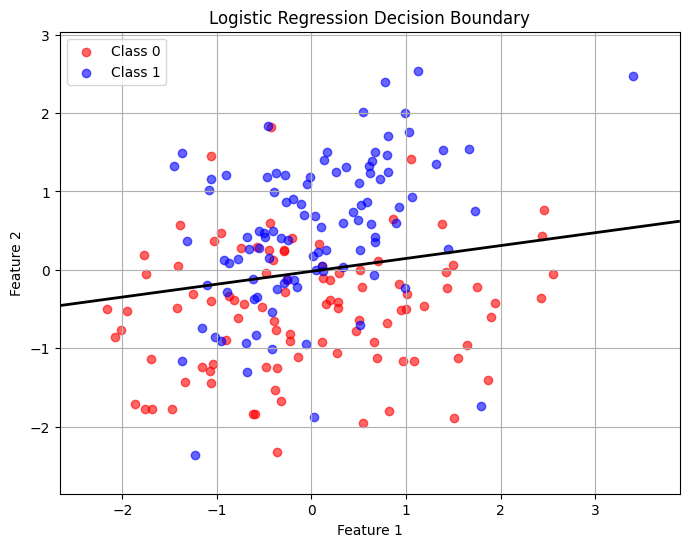

In [8]:
plt.figure(figsize=(8, 6))
#plt.contourf(xx1, xx2, probs_grid, levels=50, cmap="RdBu", alpha=0.6)
plt.contour(xx1, xx2, probs_grid, levels=[0.5], colors='black', linewidths=2)
plt.scatter(x[y == 0][:, 0], x[y == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(x[y == 1][:, 0], x[y == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


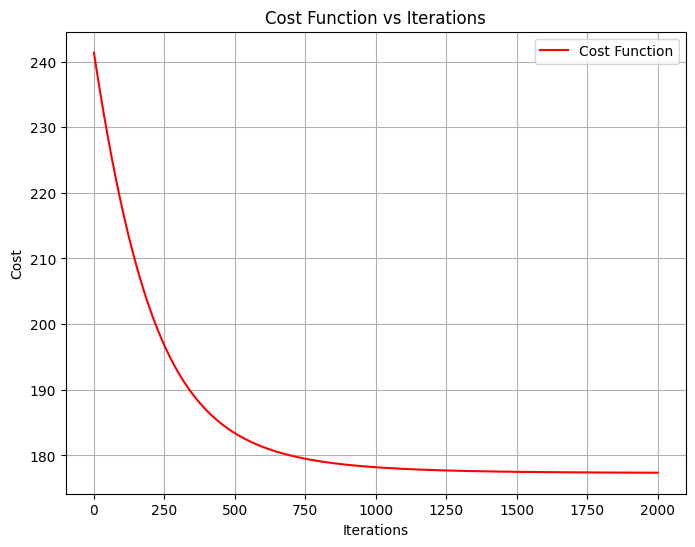

In [9]:
# Create figure for cost visualization
plt.figure(figsize=(8, 6))
plt.plot(cost_, color='red', label="Cost Function")
plt.title("Cost Function vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid(True)
plt.show()